# Предсказание оттока клиентов

Цель данной задачи предсказать, какие клиенты могут от нас уйти, для того, чтобы предложить им скидки , акции, бонусы и тд

`Математическая задача` - задача бинарной классификации c оцениваем вероятности ухода клиента

In [1]:
!pip install imbalanced-learn

загрузим все необходимые библиотеки

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from catboost import Pool, CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline 

SEED = 28

In [3]:
data = pd.read_csv("/kaggle/input/competitions/advanced-dls-spring-2021/train.csv")

test = pd.read_csv("/kaggle/input/competitions/advanced-dls-spring-2021/test.csv")

In [4]:
display(data.head(10))

print(f"Размер датасета: {data.shape}")

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0
5,25,19.80,475.2,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
6,27,90.15,2423.4,Female,0,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,No,Bank transfer (automatic),0
7,1,45.70,45.7,Male,0,No,No,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,1
8,50,105.95,5341.8,Male,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,No,Credit card (automatic),1
9,72,61.20,4390.25,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),0


Размер датасета: (5282, 20)


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

## EDA 

In [6]:
data[(data["TotalSpent"] == " ") | (data["ClientPeriod"] == 0)]

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1048,0,25.75,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
1707,0,73.35,,Female,0,Yes,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,0
2543,0,19.70,,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,0
3078,0,80.85,,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,0
3697,0,20.00,,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4002,0,61.90,,Male,0,No,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
4326,0,25.35,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4551,0,52.55,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),0
4598,0,56.05,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0


In [7]:
data[(data["TotalSpent"] == " ") | (data["ClientPeriod"] == 1)]

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
7,1,45.70,45.7,Male,0,No,No,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,1
51,1,74.45,74.45,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,1
63,1,48.45,48.45,Female,0,No,No,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),0
67,1,24.40,24.4,Male,0,No,No,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5192,1,69.65,69.65,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,1
5199,1,19.70,19.7,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
5257,1,19.20,19.2,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
5265,1,85.80,85.8,Female,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,1


In [8]:
data[(data["TotalSpent"] == " ") | (data["ClientPeriod"] == 0)]["MonthlySpending"].values

array([25.75, 73.35, 19.7 , 80.85, 20.  , 61.9 , 25.35, 52.55, 56.05])

У нас есть клиенты, которые только присоединились к данной телеком компании и у них есть месячная стоимость, но их TotalSpent равен нулю, так как не прошел даже один период пользования данной компанией. Но их минимальные Общие траты составят минимум сумма, оплаченную за первый месяц. Поэтому приравняем MonthlySpending к TotalSpent для `ClientPeriod = 0`

In [9]:
mask = (data["TotalSpent"] == " ") | (data["ClientPeriod"] == 0)

data.loc[mask, "TotalSpent"] = data.loc[mask, "MonthlySpending"]

data["TotalSpent"] = data["TotalSpent"].astype("float")

In [10]:
# Числовые признаки
num_cols = [
    'ClientPeriod', # Сколько времени клиент пользуется оператором
    'MonthlySpending', # Сумма пораченных денег в месяц клиентом
    'TotalSpent' # Общая сумма потраченных денег клиентом
]

# Категориальные признаки
cat_cols = [
    'Sex', # Пол клиента
    'IsSeniorCitizen', # В возрасте ли человек (1/0)
    'HasPartner', # Наличие партнера
    'HasChild', # Наличие детей
    'HasPhoneService', # Пользуется ли мобильным сервисом телеком компании
    'HasMultiplePhoneNumbers', # Наличие несколько номеров
    'HasInternetService', # Наличие интернет сервисом компании
    'HasOnlineSecurityService', # Наличие услуги блокировки опасных сайтов
    'HasOnlineBackup', # Облачное хранилище для бэкапов
    'HasDeviceProtection', # Страховка оборудования
    'HasTechSupportAccess', # Наличие доступа к тех.поддержки
    'HasOnlineTV', # Наличие ТВ
    'HasMovieSubscription', # Наличие подписки на кино
    'HasContractPhone', # Общая сумма потраченных денег клиентом
    'IsBillingPaperless', # Выставление электронного счета
    'PaymentMethod' # Метод оплаты
]

target_col = 'Churn'

проверим данные на пропуски

<Axes: >

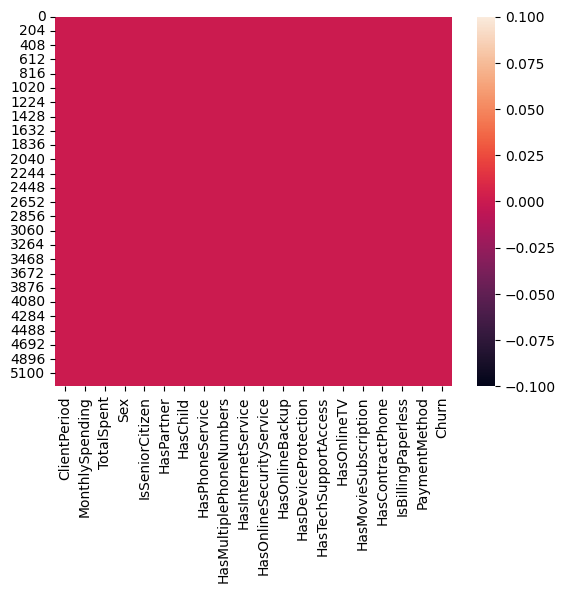

In [11]:
sns.heatmap(data.isnull())

посмотрим на зависимость численных признаков от целевого, а также их распределения

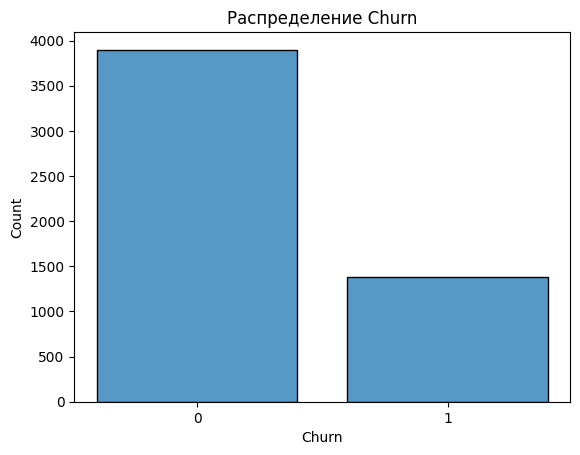

In [12]:
sns.histplot(data, x="Churn", shrink=0.8, discrete=True)
plt.title("Распределение Churn")
plt.xticks([0, 1])
plt.show()

У нас есть дисбаланс классов выраженный. Далее попробуем oversampling для балансировки классов

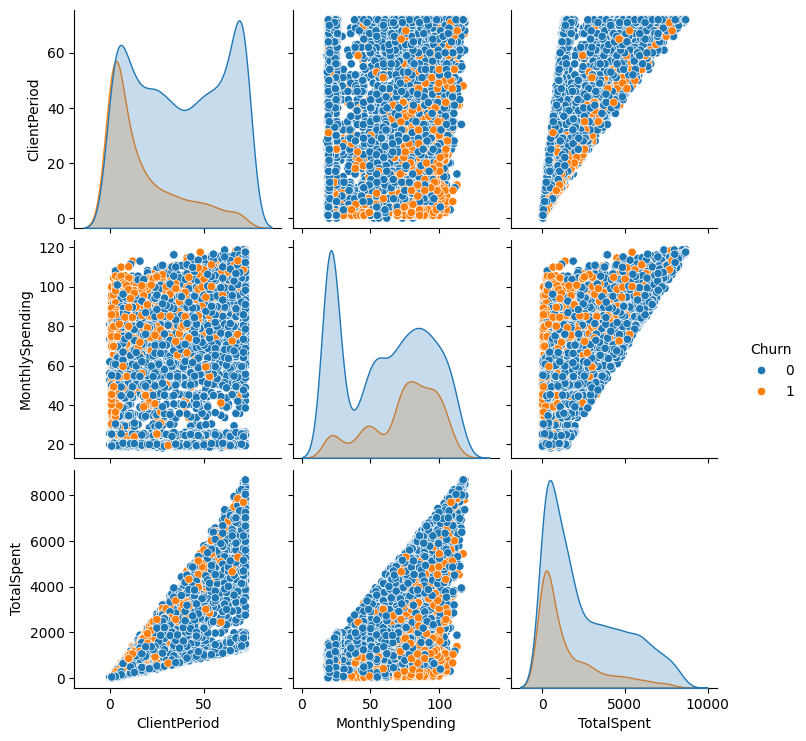

In [13]:
sns.pairplot(data, vars=num_cols, hue="Churn", diag_kind="kde")

Значения в признаках для классов линейно не разделимы

Посмотрим на зависимость ухода клиента от месячной стоимости

<Axes: xlabel='MonthlySpending', ylabel='Count'>

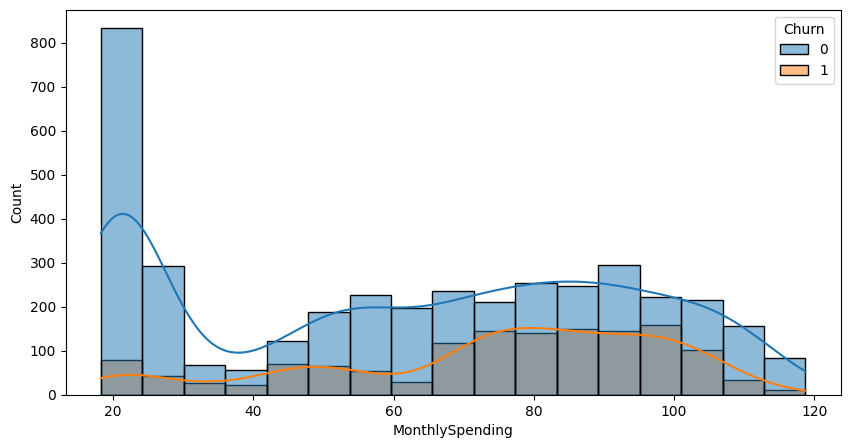

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(data, x="MonthlySpending", hue="Churn", kde=True)

Вероятно, клиенты, которые платят стоимость выше среднего, недевольны качеством при такой цене, в связи с чем они расторгают контракт. Люди , которые платят минимум - пробуют услуги, максимум - лояльны к данной компании

Потроим гистограммы категориальных признаков по целевому

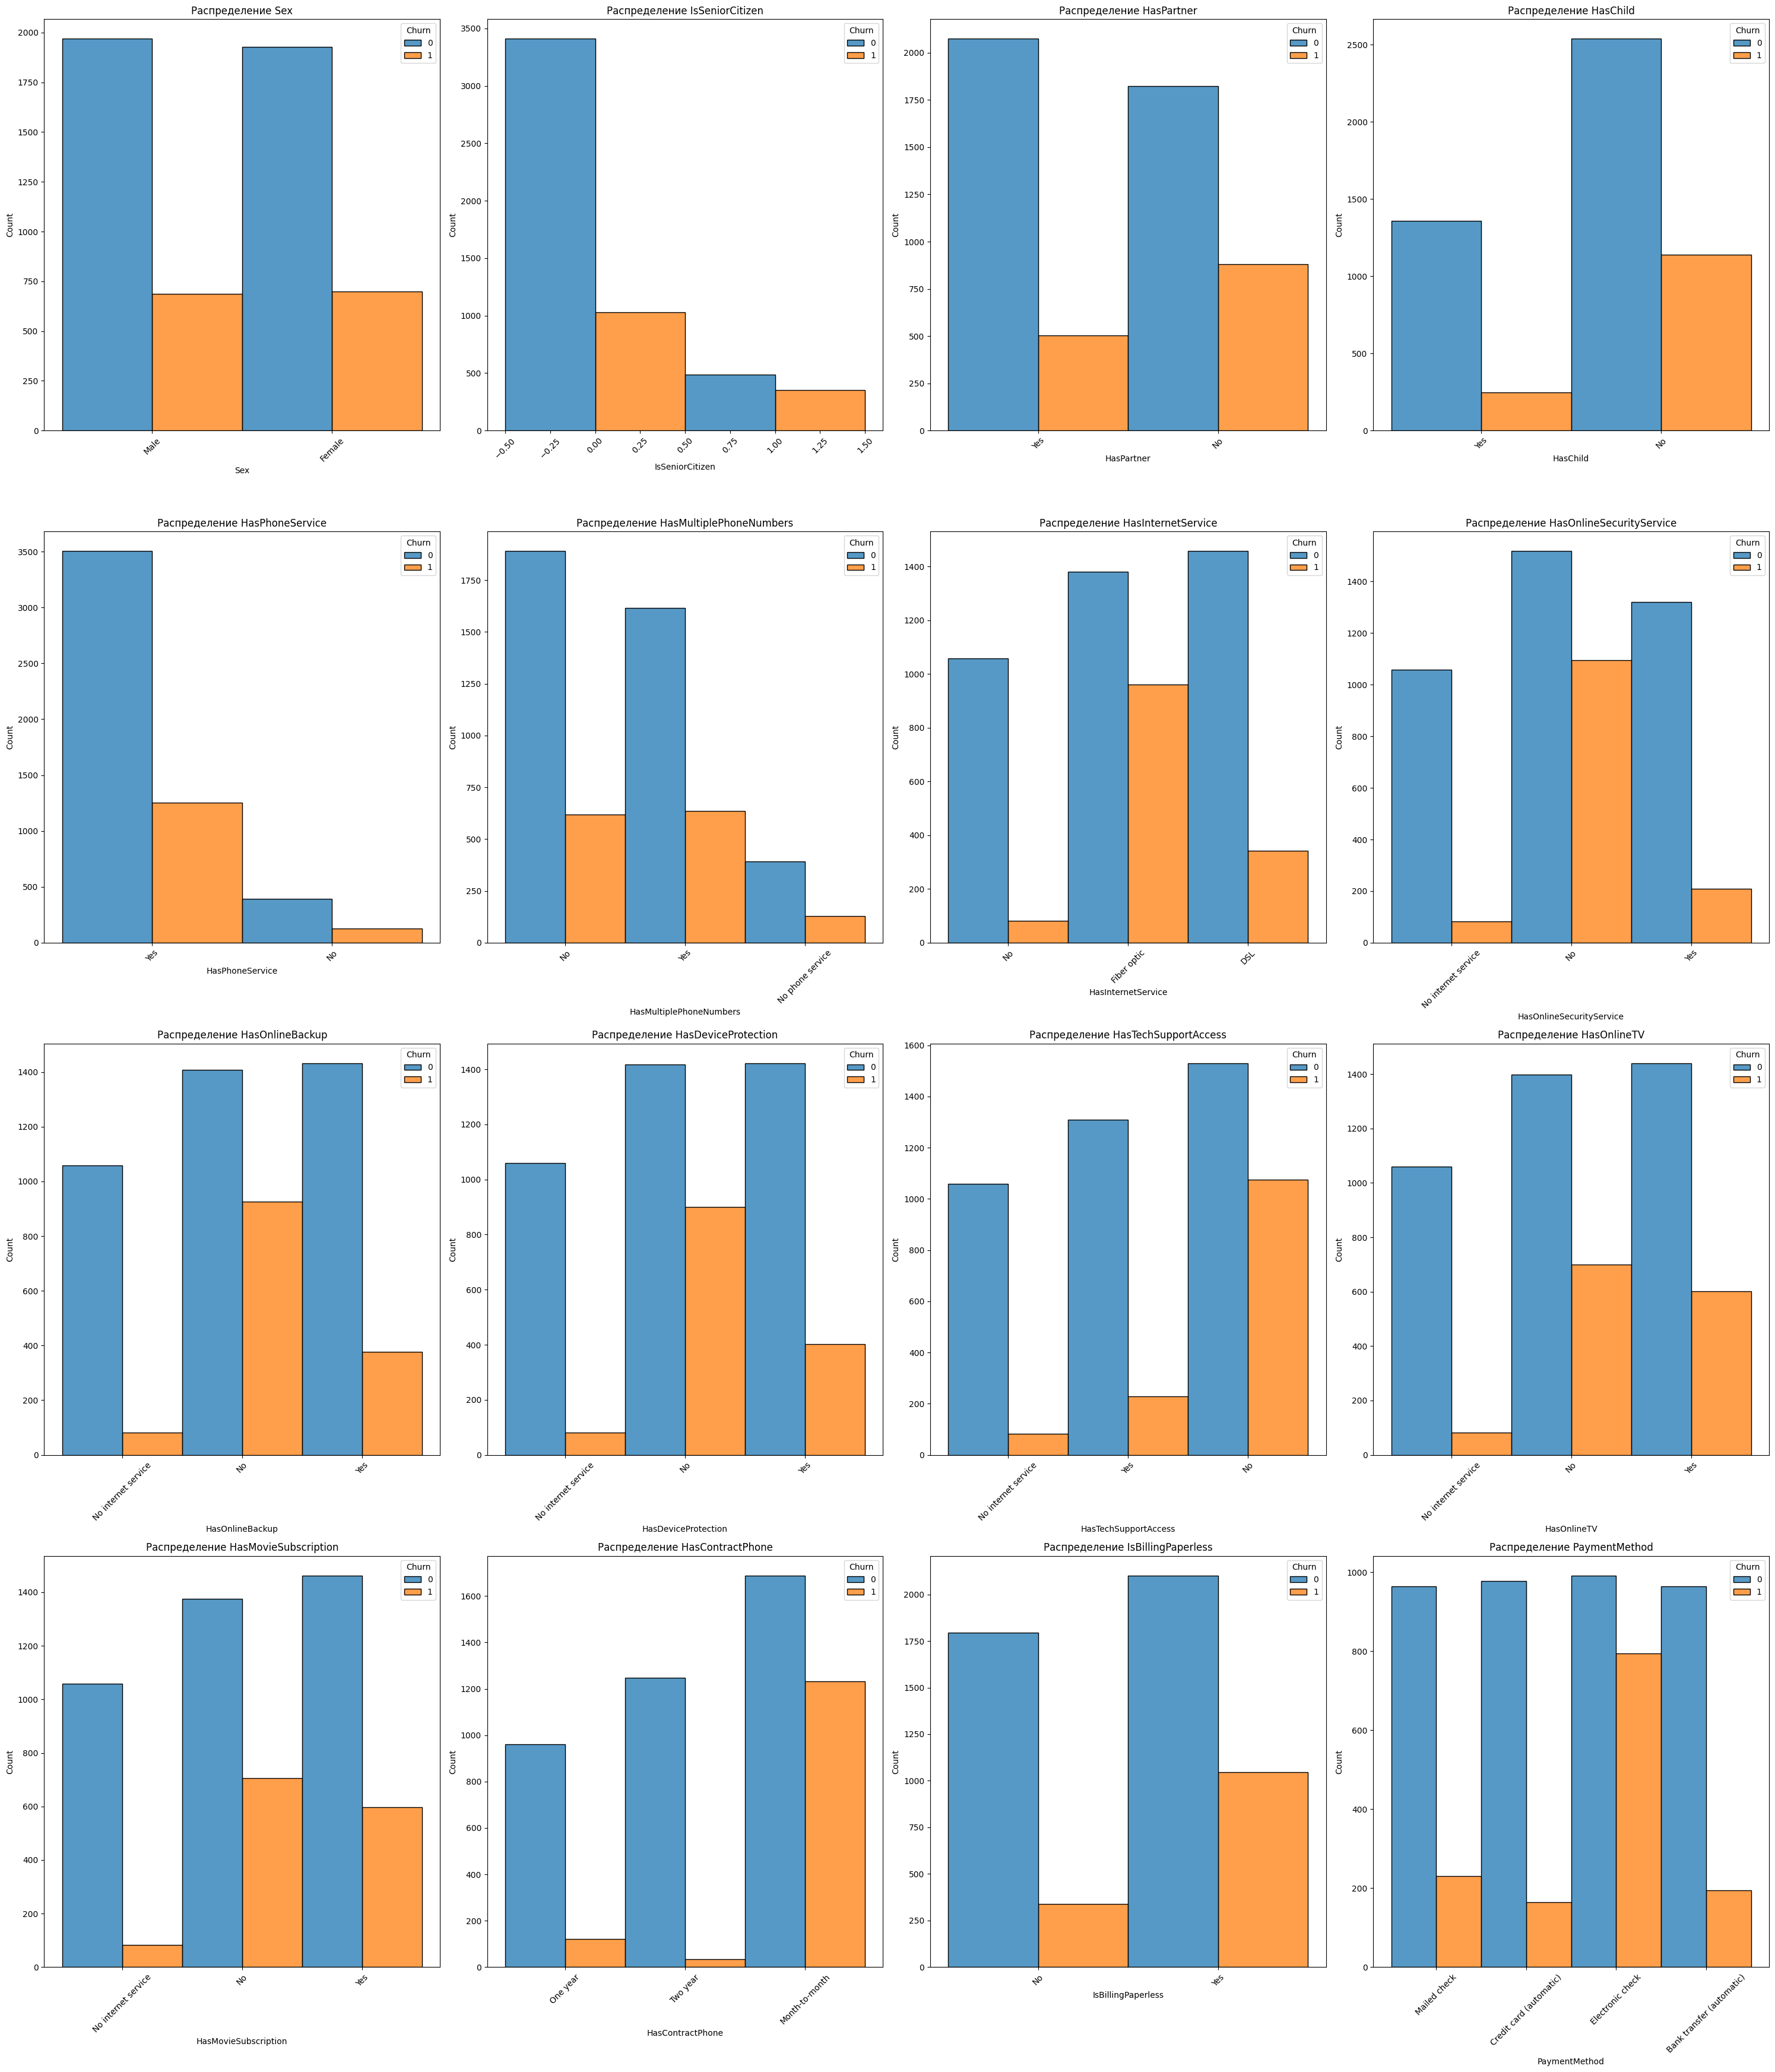

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(30,35))

for col, ax in zip(cat_cols, axes.ravel()):
    ax.set_title(f"Распределение {col}")
    sns.histplot(data, x=col, discrete=True, ax=ax, shrink= 1, hue="Churn", multiple="dodge")
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

посмотрим на таблицу корреляций

In [16]:
data[num_cols + [target_col]].corr()

,ClientPeriod,MonthlySpending,TotalSpent,Churn
ClientPeriod,1.000000,0.249414,0.826641,-0.350640
MonthlySpending,0.249414,1.000000,0.652027,0.184769
TotalSpent,0.826641,0.652027,1.000000,-0.200061
Churn,-0.350640,0.184769,-0.200061,1.000000


## Preprocessing

разделим наши признаки на группы для их кодирования

In [17]:
cols_done = num_cols + [
    "IsSeniorCitizen"
]

cols_binary = [
    "Sex",
    "HasPartner",
    "HasChild",
    "HasPhoneService",
    "IsBillingPaperless"
]
cols_binary_label = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

cols_rank = [
    "HasContractPhone",
    "HasInternetService"
]

cols_ohe = data.columns.difference(cols_done + cols_binary + cols_rank).tolist()
cols_ohe.remove("Churn")

In [18]:
cols_ohe

['HasDeviceProtection',
 'HasMovieSubscription',
 'HasMultiplePhoneNumbers',
 'HasOnlineBackup',
 'HasOnlineSecurityService',
 'HasOnlineTV',
 'HasTechSupportAccess',
 'PaymentMethod']

закодируем категориальне признаки

In [19]:
for col in cols_binary:
    data[col] = data[col].replace(cols_binary_label).astype(int)

/tmp/ipykernel_16/3691645708.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace(cols_binary_label).astype(int)
/tmp/ipykernel_16/3691645708.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace(cols_binary_label).astype(int)
/tmp/ipykernel_16/3691645708.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior,

In [20]:
contract_order = ['Month-to-month', 'One year', 'Two year']
internet_order = ['No', 'DSL', 'Fiber optic']

ordinal_en = OrdinalEncoder(categories=[contract_order, internet_order])

cols_rank_transormed = ordinal_en.fit_transform(data[cols_rank])
cols_rank_transormed_df = pd.DataFrame(cols_rank_transormed , columns=cols_rank, index=data.index)

In [21]:
ohe = OneHotEncoder(sparse_output=False)

cols_ohe_transformed = ohe.fit_transform(data[cols_ohe])
cols_ohe_transformed_df = pd.DataFrame(cols_ohe_transformed, columns=ohe.get_feature_names_out(), index=data.index)

In [22]:
data_transformed =  pd.concat([data[cols_done], data[cols_binary], cols_rank_transormed_df, cols_ohe_transformed_df], axis=1)

In [23]:
data_transformed.head()

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Sex,HasPartner,HasChild,HasPhoneService,IsBillingPaperless,HasContractPhone,...,HasOnlineTV_No,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasTechSupportAccess_No,HasTechSupportAccess_No internet service,HasTechSupportAccess_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,55,19.50,1026.35,0,1,1,1,1,0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,72,25.85,1872.20,0,1,1,0,1,0,2.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1,75.90,75.90,0,1,0,0,1,1,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,32,79.30,2570.00,1,0,1,0,1,0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,60,115.25,6758.45,0,0,1,1,1,0,2.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


разделим данные на train и test

In [24]:
X = data_transformed
y = data["Churn"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

применим стандартизацию к данным

In [26]:
scaler = StandardScaler()

X_train_scaled_num = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
X_test_scaled_num = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

In [27]:
X_train_scaled = pd.concat([X_train_scaled_num, X_train.loc[:, X_train.columns.difference(num_cols)]], axis=1)
X_test_scaled = pd.concat([X_test_scaled_num, X_test.loc[:, X_test.columns.difference(num_cols)]], axis=1)

применим oversampling для train

In [28]:
smote = SMOTE(random_state=SEED, sampling_strategy='auto', k_neighbors=8)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

## Baseline 

In [29]:
knn_model = KNeighborsClassifier(n_jobs=-1, n_neighbors=100, weights="distance")

knn_model.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_jobs=-1, n_neighbors=100, weights='distance')

In [30]:
y_pred = knn_model.predict(X_test_scaled)
y_pred_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1-score: {f1_score(y_test, y_pred)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob)}")

Precision: 0.4514285714285714
Recall: 0.855595667870036
F1-score: 0.5910224438902744
ROC-AUC: 0.8315653059335371


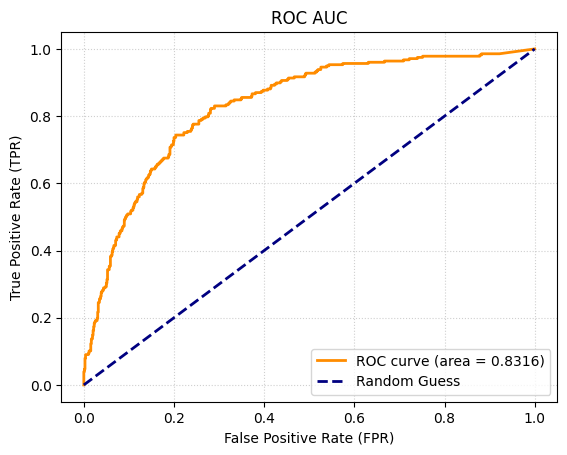

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_prob):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.title("ROC AUC")
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)


## Feature Engineering 

In [32]:
data_transformed.head()

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Sex,HasPartner,HasChild,HasPhoneService,IsBillingPaperless,HasContractPhone,...,HasOnlineTV_No,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasTechSupportAccess_No,HasTechSupportAccess_No internet service,HasTechSupportAccess_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,55,19.50,1026.35,0,1,1,1,1,0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,72,25.85,1872.20,0,1,1,0,1,0,2.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1,75.90,75.90,0,1,0,0,1,1,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,32,79.30,2570.00,1,0,1,0,1,0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,60,115.25,6758.45,0,0,1,1,1,0,2.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [33]:
data_transformed.columns

Index(['ClientPeriod', 'MonthlySpending', 'TotalSpent', 'IsSeniorCitizen',
       'Sex', 'HasPartner', 'HasChild', 'HasPhoneService',
       'IsBillingPaperless', 'HasContractPhone', 'HasInternetService',
       'HasDeviceProtection_No', 'HasDeviceProtection_No internet service',
       'HasDeviceProtection_Yes', 'HasMovieSubscription_No',
       'HasMovieSubscription_No internet service', 'HasMovieSubscription_Yes',
       'HasMultiplePhoneNumbers_No',
       'HasMultiplePhoneNumbers_No phone service',
       'HasMultiplePhoneNumbers_Yes', 'HasOnlineBackup_No',
       'HasOnlineBackup_No internet service', 'HasOnlineBackup_Yes',
       'HasOnlineSecurityService_No',
       'HasOnlineSecurityService_No internet service',
       'HasOnlineSecurityService_Yes', 'HasOnlineTV_No',
       'HasOnlineTV_No internet service', 'HasOnlineTV_Yes',
       'HasTechSupportAccess_No', 'HasTechSupportAccess_No internet service',
       'HasTechSupportAccess_Yes', 'PaymentMethod_Bank transfer (automati

In [34]:
# вес реальных трат с учетом контракта
data_transformed["Phone_TotalSpent_Log"] = np.log(data_transformed["TotalSpent"]) * \
                                                    data_transformed["HasContractPhone"]

# Относительной период (реальные траты / месячные подписки)
data_transformed["TotalToMonthlyRatio"] = data_transformed['TotalSpent'] /\
                                        (data_transformed['MonthlySpending'] + 1e-5)

# период новичка
data_transformed["IsNewClient"] = (data_transformed["ClientPeriod"] < 3).astype(int)

# автоматические платежи
data_transformed['IsAutomaticPayment'] = (
    data_transformed['PaymentMethod_Bank transfer (automatic)'] + 
    data_transformed['PaymentMethod_Credit card (automatic)']
).astype(int)

# кинолюбитель
data_transformed["HasStreaming"] = ((data_transformed['HasMovieSubscription_Yes'] == 1) |\
                                    (data_transformed['HasOnlineTV_Yes'] == 1)).astype(int)

In [35]:
num_cols = num_cols + ["Phone_TotalSpent_Log", "TotalToMonthlyRatio"]
cat_cols = data_transformed.columns.difference(num_cols).tolist()

In [36]:
X = data_transformed
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

## Experiments

данная обертку нужна, чтобы catboost не сравнивал параметры по адресу ячейки в памяти при копировании

In [37]:
class FixedCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return FixedCatBoostClassifier(**self.get_params())

создадим цельный pipeline

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), num_cols) 
    ],
    remainder="passthrough"
)

estimators = [
    ("catboost", FixedCatBoostClassifier(
        iterations=1500, 
        depth=5, 
        learning_rate=0.01,
        bootstrap_type="Bernoulli",
        subsample=0.8,
        verbose=0,
        loss_function='Logloss',
        thread_count=-1
        
    )),
    ("knn", KNeighborsClassifier(n_jobs=-1, n_neighbors=100, weights="distance")) ,
    ('rf', RandomForestClassifier(n_estimators=200, random_state=SEED, max_depth=15, criterion="entropy", warm_start=True))
]

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("oversampling", SMOTE(random_state=SEED, sampling_strategy='auto', k_neighbors=7)),
    ("model", StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), n_jobs=-1))
])

full_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['ClientPeriod',
                                                   'MonthlySpending',
                                                   'TotalSpent',
                                                   'Phone_TotalSpent_Log',
                                                   'TotalToMonthlyRatio'])])),
                ('oversampling', SMOTE(k_neighbors=7, random_state=28)),
                ('model',
                 StackingClassifier(estimators=[('catboost',
                                                 FixedCatBoostClassifier(bootstrap_type='Bernoulli', depth=5, iterations=1500, learning_rate=0.01, loss_function='Logloss', subsample=0.8, verbose=0)),
                                                ('knn',
                                                 KNeighborsClassifier(n_jobs=-1,
                                                                      n_neighbors=100,
                                                                      weights='distance')),
                                                ('rf',
                                                 RandomForestClassifier(criterion='entropy',
                                                                        max_depth=15,
                                                                        n_estimators=200,
                                                                        random_state=28,
                                                                        warm_start=True))],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=-1))])

In [39]:
full_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['ClientPeriod',
                                                   'MonthlySpending',
                                                   'TotalSpent',
                                                   'Phone_TotalSpent_Log',
                                                   'TotalToMonthlyRatio'])])),
                ('oversampling', SMOTE(k_neighbors=7, random_state=28)),
                ('model',
                 StackingClassifier(estimators=[('catboost',
                                                 FixedCatBoostClassifier(bootstrap_type='Bernoulli', depth=5, iterations=1500, learning_rate=0.01, loss_function='Logloss', subsample=0.8, verbose=0)),
                                                ('knn',
                                                 KNeighborsClassifier(n_jobs=-1,
                                                                      n_neighbors=100,
                                                                      weights='distance')),
                                                ('rf',
                                                 RandomForestClassifier(criterion='entropy',
                                                                        max_depth=15,
                                                                        n_estimators=200,
                                                                        random_state=28,
                                                                        warm_start=True))],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=-1))])

In [40]:
y_pred = full_pipeline.predict(X_test)
y_pred_prob = full_pipeline.predict_proba(X_test)[:, 1]

print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1-score: {f1_score(y_test, y_pred)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob)}")

Precision: 0.5915492957746479
Recall: 0.6064981949458483
F1-score: 0.5989304812834224
ROC-AUC: 0.8514486716652783


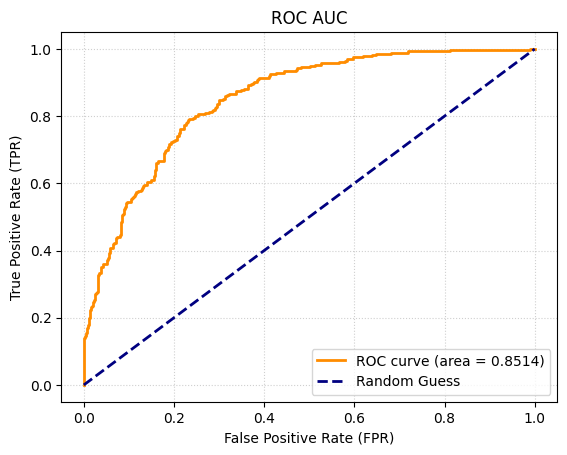

In [41]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_prob):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.title("ROC AUC")
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

попытался использовать байесовскую оптимизацию, но она оказалась довольно долгой и результат не принесла

In [42]:
# !pip install optuna

In [43]:
# import optuna
# from sklearn.model_selection import cross_val_score

# def objective(trial):
#     bootstrap_type = trial.suggest_categorical("cat_bootstrap", ["Bernoulli", "Bayesian"])
    
#     catboost_params = {
#         "iterations": trial.suggest_int("cat_iter", 500, 1200, step=100),
#         "depth": trial.suggest_int("cat_depth", 4, 6),
#         "learning_rate": trial.suggest_float("cat_lr", 0.01, 0.08, log=True),
#         "bootstrap_type": bootstrap_type,
#         "loss_function": "Logloss",
#         "verbose": 0,
#         "task_type": "CPU",
#         "random_seed": SEED,
#         "l2_leaf_reg": trial.suggest_float("cat_l2", 1.0, 10.0),
#         "random_strength": trial.suggest_float("cat_random_strength", 1e-3, 10.0, log=True),
#         "rsm": trial.suggest_float("cat_rsm", 0.6, 1.0),
#     }
    
#     if bootstrap_type == "Bernoulli":
#         catboost_params["subsample"] = trial.suggest_float("cat_subsample", 0.6, 0.9)
#         full_pipeline.set_params(model__catboost__bagging_temperature=None)
#         full_pipeline.set_params(model__catboost__subsample=catboost_params["subsample"])
#     elif bootstrap_type == "Bayesian":
#         catboost_params["bagging_temperature"] = trial.suggest_float("cat_bagging_temp", 0.0, 1.0)
#         full_pipeline.set_params(model__catboost__subsample=None)
#         full_pipeline.set_params(model__catboost__bagging_temperature=catboost_params["bagging_temperature"])

#     rf_params = {
#         "n_estimators": trial.suggest_int("rf_estimators", 100, 250, step=50),
#         "max_depth": trial.suggest_int("rf_max_depth", 8, 15),
#         "min_samples_split": trial.suggest_int("rf_split", 6, 14),
#     }
    
#     knn_params = {
#         "n_neighbors": trial.suggest_int("knn_neighbors", 40, 100, step=10),
#         "weights": trial.suggest_categorical("knn_weights", ["uniform", "distance"]),
#     }
    
#     full_pipeline.set_params(
#         model__catboost__bootstrap_type=catboost_params["bootstrap_type"],
#         model__catboost__iterations=catboost_params["iterations"],
#         model__catboost__depth=catboost_params["depth"],
#         model__catboost__learning_rate=catboost_params["learning_rate"],
#         model__catboost__l2_leaf_reg=catboost_params["l2_leaf_reg"],         
#         model__catboost__random_strength=catboost_params["random_strength"], 
#         model__catboost__rsm=catboost_params["rsm"],                    
#         model__catboost__task_type="CPU",
        
#         model__rf__n_estimators=rf_params["n_estimators"],
#         model__rf__max_depth=rf_params["max_depth"],
#         model__rf__min_samples_split=rf_params["min_samples_split"],
        
#         model__knn__n_neighbors=knn_params["n_neighbors"],
#         model__knn__weights=knn_params["weights"]
#     )
    
#     # Кросс-валидация
#     scores = cross_val_score(
#         full_pipeline, 
#         X_train, 
#         y_train, 
#         cv=3, 
#         scoring="roc_auc", 
#         n_jobs=-1
#     )
    
#     return scores.mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=20) 

# print("Лучший ROC-AUC:", study.best_value)
# print("Лучшие параметры:", study.best_params)
# # 